**Computación Cuántica II**
# Sebastián González Juárez
Práctica de laboratorio 1.

## a.	Crea un circuito sencillo en PennyLane y busca distintos tipos de draw. Y me expliques cuál es tu favorito y por qué.

In [1]:
!python --version
!pip install -q --upgrade pip
!pip install -q pennylane matplotlib

Python 3.12.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.0 MB/s eta 0:00:00


In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

print("PennyLane version:", qml.__version__)
print("Estilos disponibles:", qml.drawer.available_styles())

PennyLane version: 0.44.1
Estilos disponibles: ('black_white', 'black_white_dark', 'sketch', 'pennylane', 'pennylane_sketch', 'sketch_dark', 'solarized_light', 'solarized_dark', 'default')


In [3]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

x = np.array([0.20, 0.40, 0.60, 0.80])
theta_0 = np.array([0.11, 0.22, 0.33, 0.44])
phi_0   = np.array([0.15, 0.25, 0.35, 0.45])

theta_1 = np.array([0.51, 0.62, 0.73, 0.84])
phi_1   = np.array([0.18, 0.28, 0.38, 0.48])

def ring_cnot():
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 0])

@qml.qnode(dev)
def circuito_Sebas():
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits):
        qml.RY(theta_0[i], wires=i)
    for i in range(n_qubits):
        qml.RZ(phi_0[i], wires=i)

    ring_cnot()

    for i in range(n_qubits):
        qml.RY(theta_1[i], wires=i)
    for i in range(n_qubits):
        qml.RZ(phi_1[i], wires=i)

    ring_cnot()

    return qml.probs(wires=range(n_qubits))

In [4]:
probs = circuito_Sebas()
print("Probabilidades:")
print(probs)
print("Suma de probabilidades:", np.sum(probs))

Probabilidades:
[0.24730297 0.01407562 0.00166658 0.00118146 0.05954204 0.14975303
 0.00347315 0.00475648 0.00392837 0.02720012 0.17215346 0.13493514
 0.0066478  0.01530369 0.11999096 0.03808911]
Suma de probabilidades: 1.0


In [6]:
print(qml.draw(circuito_Sebas)())

0: ──RY(0.20)──RY(0.11)──RZ(0.15)─╭●───────╭X──RY(0.51)──RZ(0.18)─╭●───────╭X─┤ ╭Probs
1: ──RY(0.40)──RY(0.22)──RZ(0.25)─╰X─╭●────│───RY(0.62)──RZ(0.28)─╰X─╭●────│──┤ ├Probs
2: ──RY(0.60)──RY(0.33)──RZ(0.35)────╰X─╭●─│───RY(0.73)──RZ(0.38)────╰X─╭●─│──┤ ├Probs
3: ──RY(0.80)──RY(0.44)──RZ(0.45)───────╰X─╰●──RY(0.84)──RZ(0.48)───────╰X─╰●─┤ ╰Probs


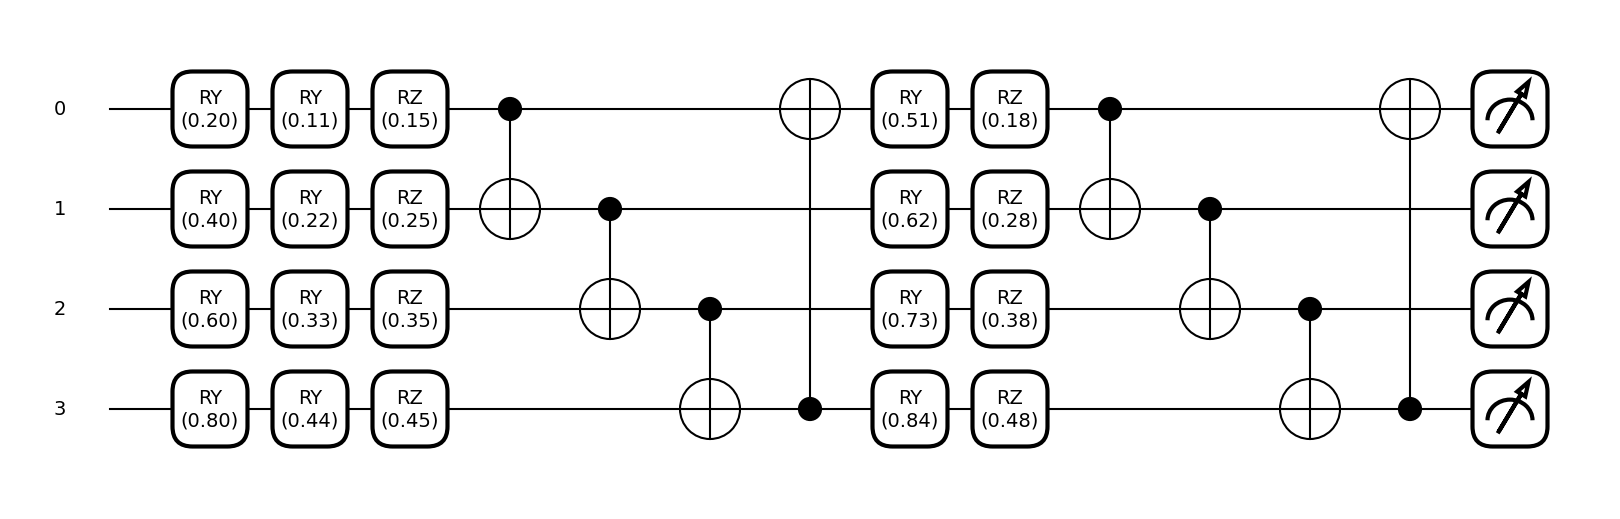

In [11]:
fig, ax = qml.draw_mpl(circuito_Sebas, decimals=2)()
plt.show()

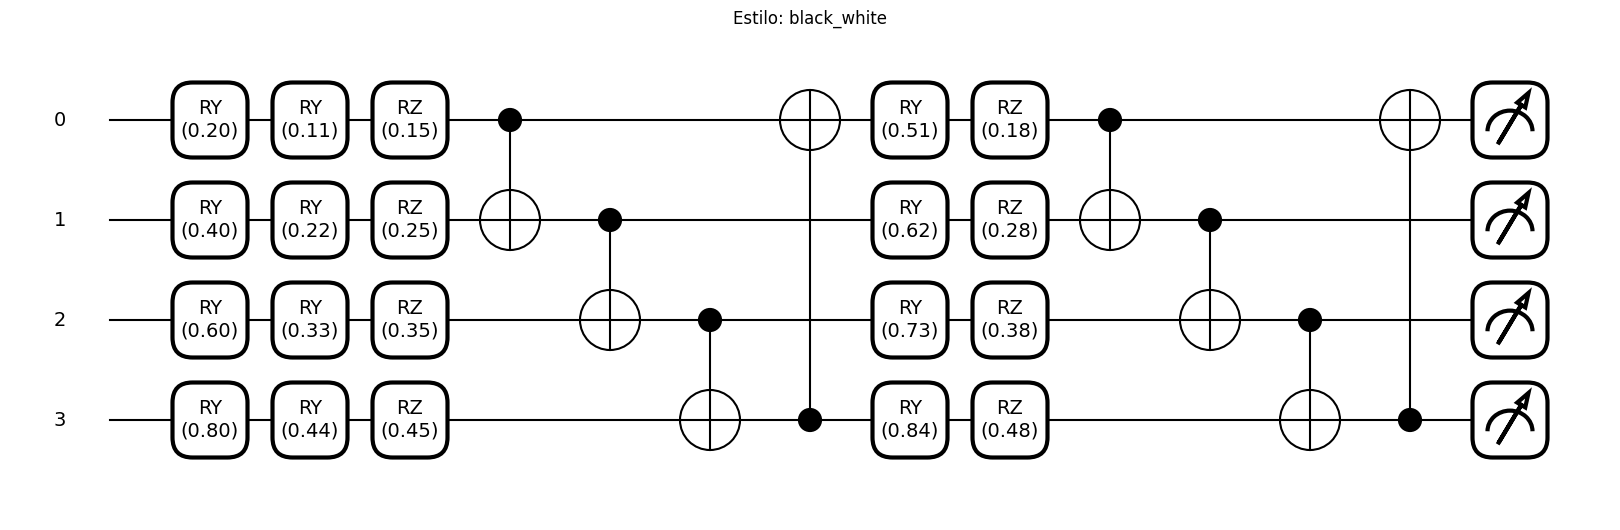

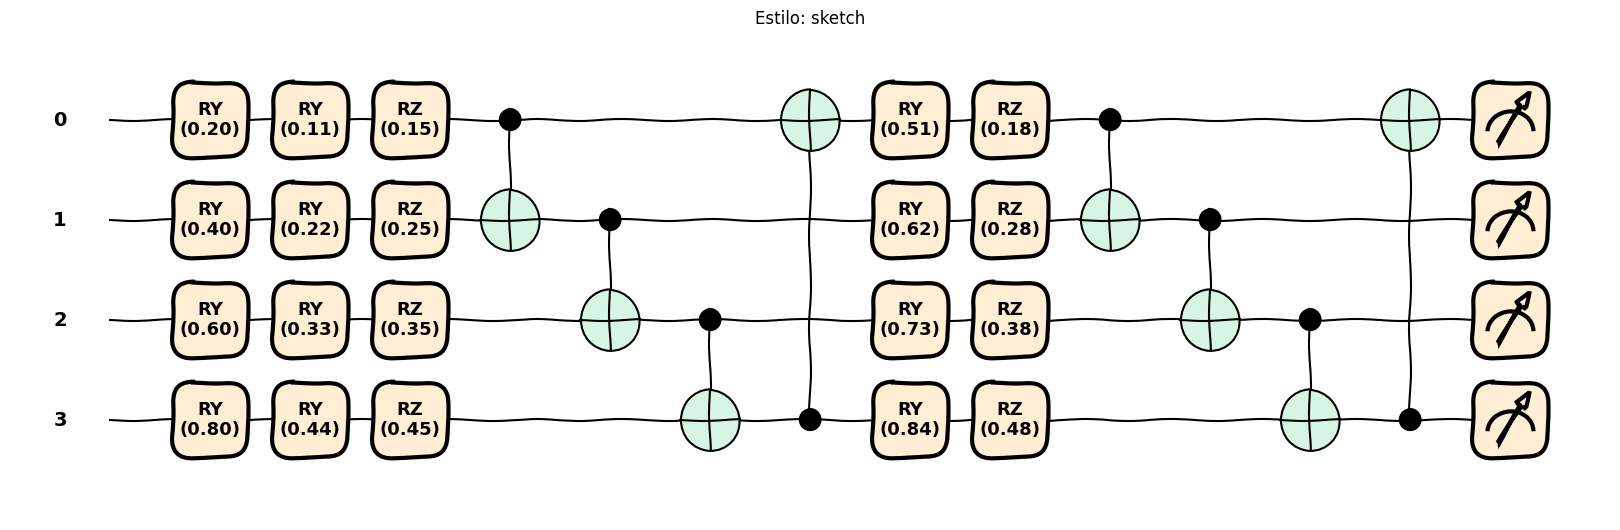

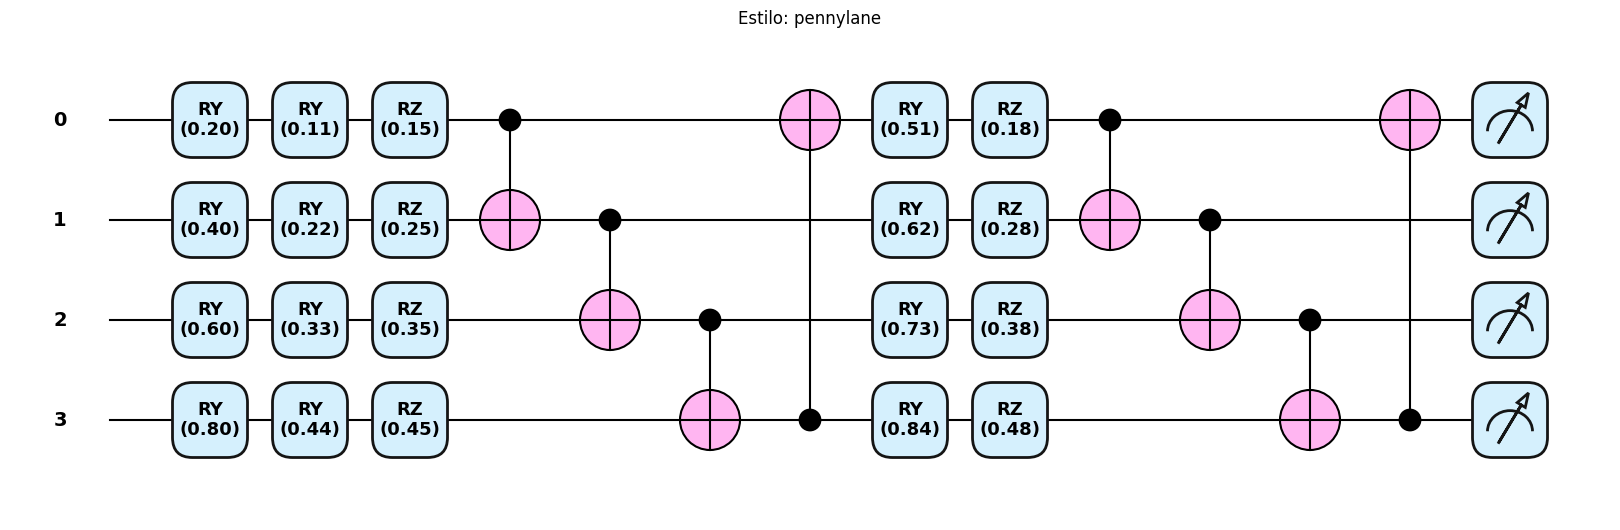

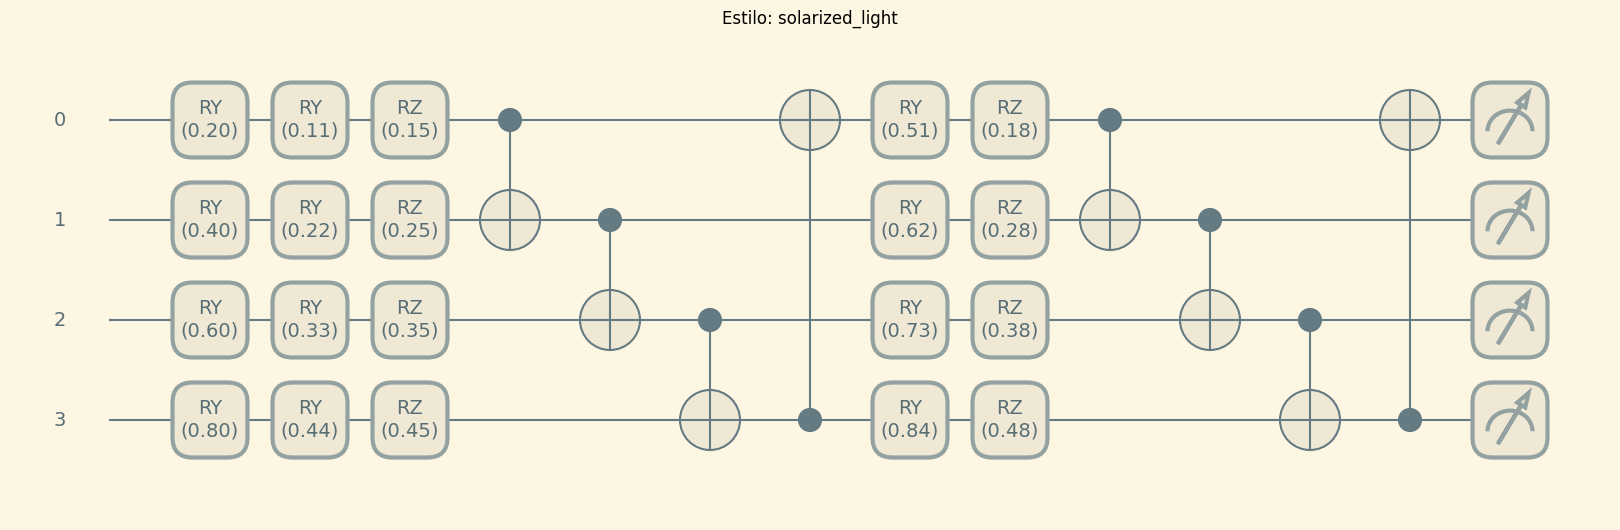

In [13]:
estilos_a_probar = ["black_white", "sketch", "pennylane", "solarized_light"]

for estilo in estilos_a_probar:
    fig, ax = qml.draw_mpl(circuito_Sebas, decimals=2, style=estilo)()
    fig.suptitle(f"Estilo: {estilo}", y=1.02)
    plt.show()

In [14]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

print("PennyLane:", qml.__version__)
print("Estilos disponibles:", qml.drawer.available_styles())

PennyLane: 0.44.1
Estilos disponibles: ('black_white', 'black_white_dark', 'sketch', 'pennylane', 'pennylane_sketch', 'sketch_dark', 'solarized_light', 'solarized_dark', 'default')


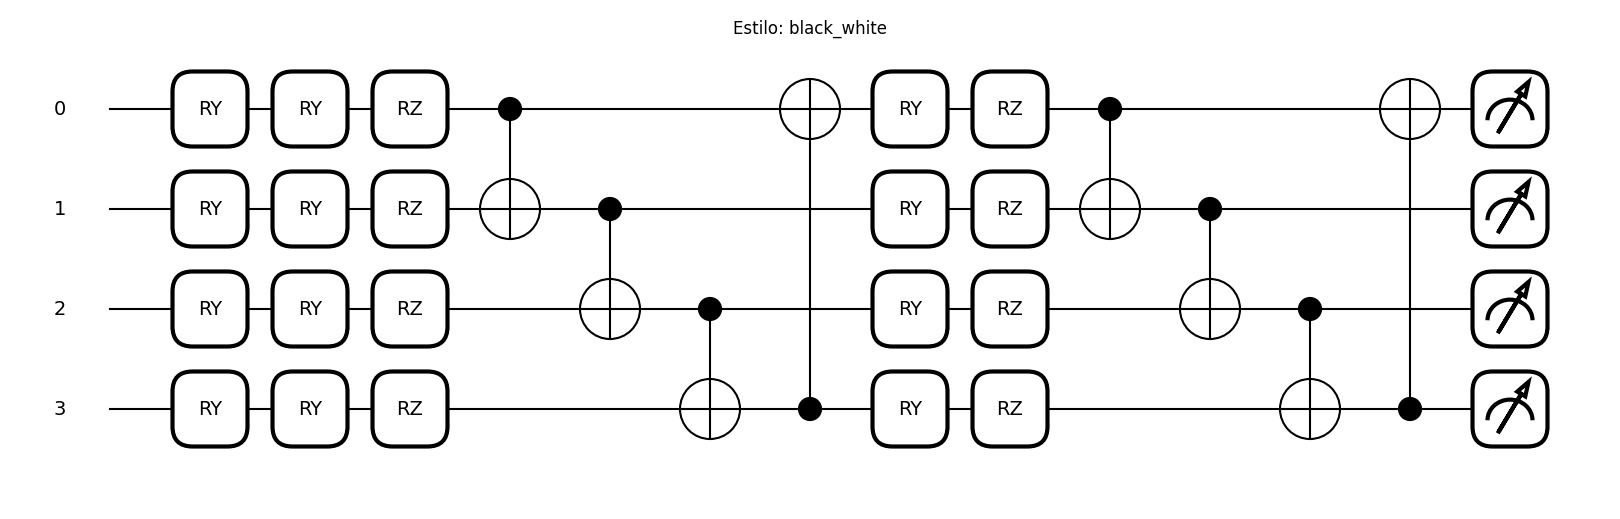

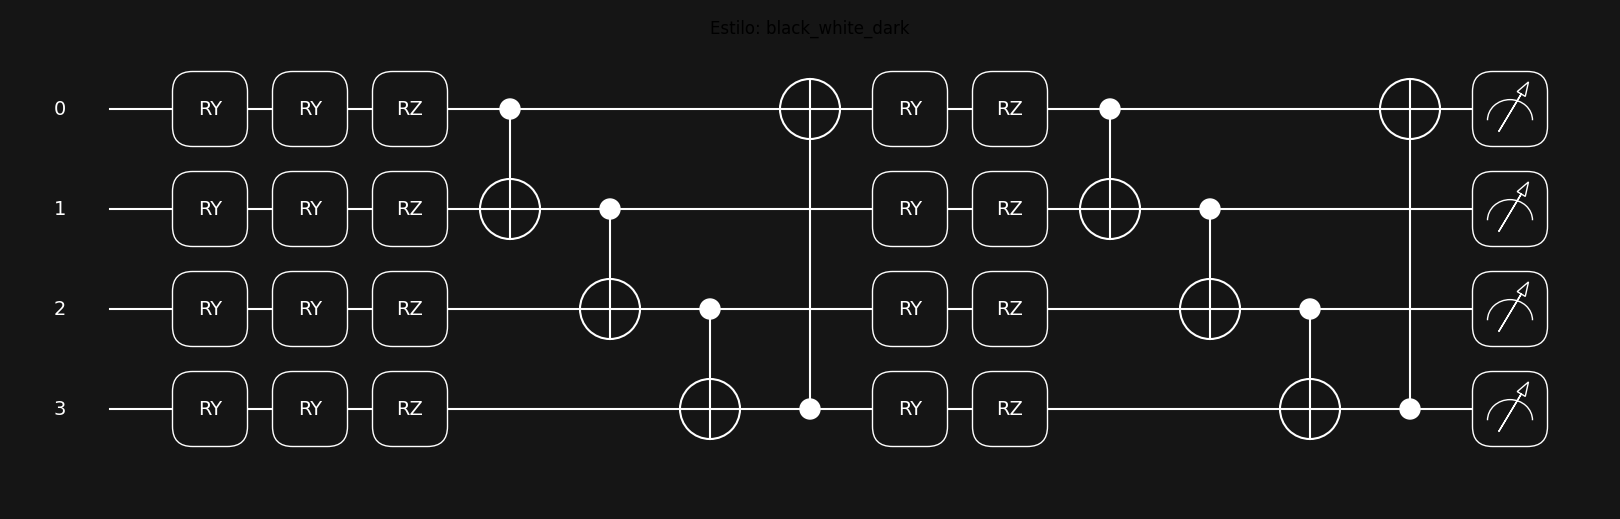

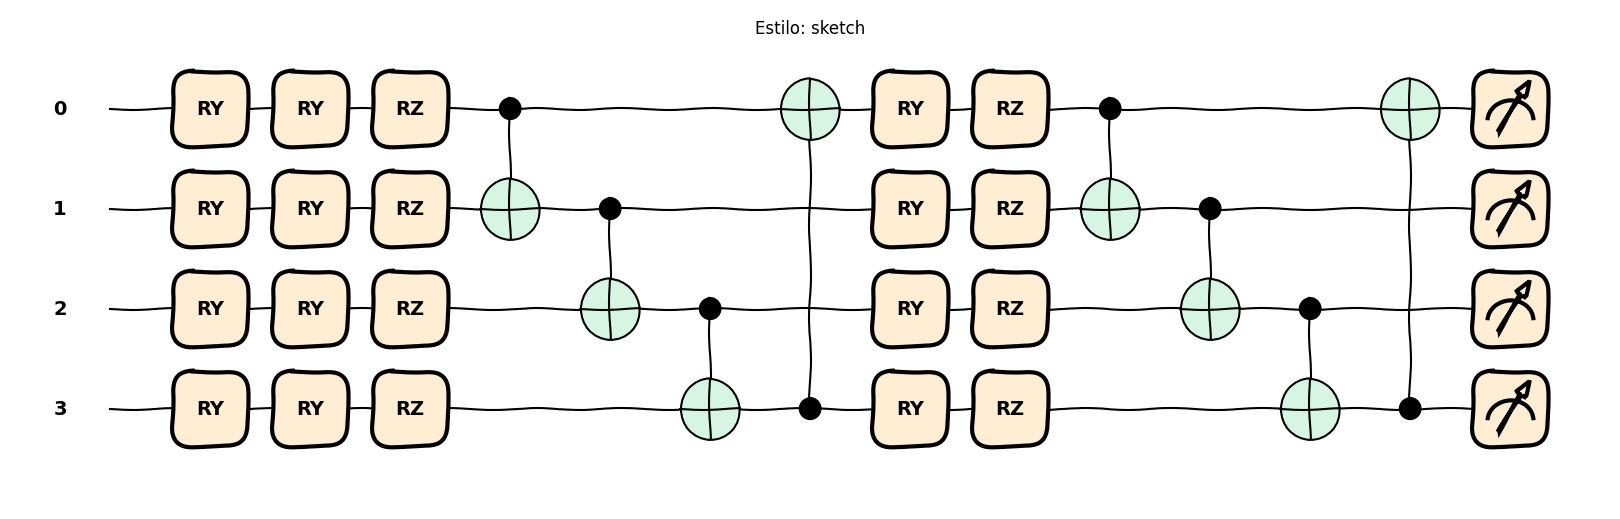

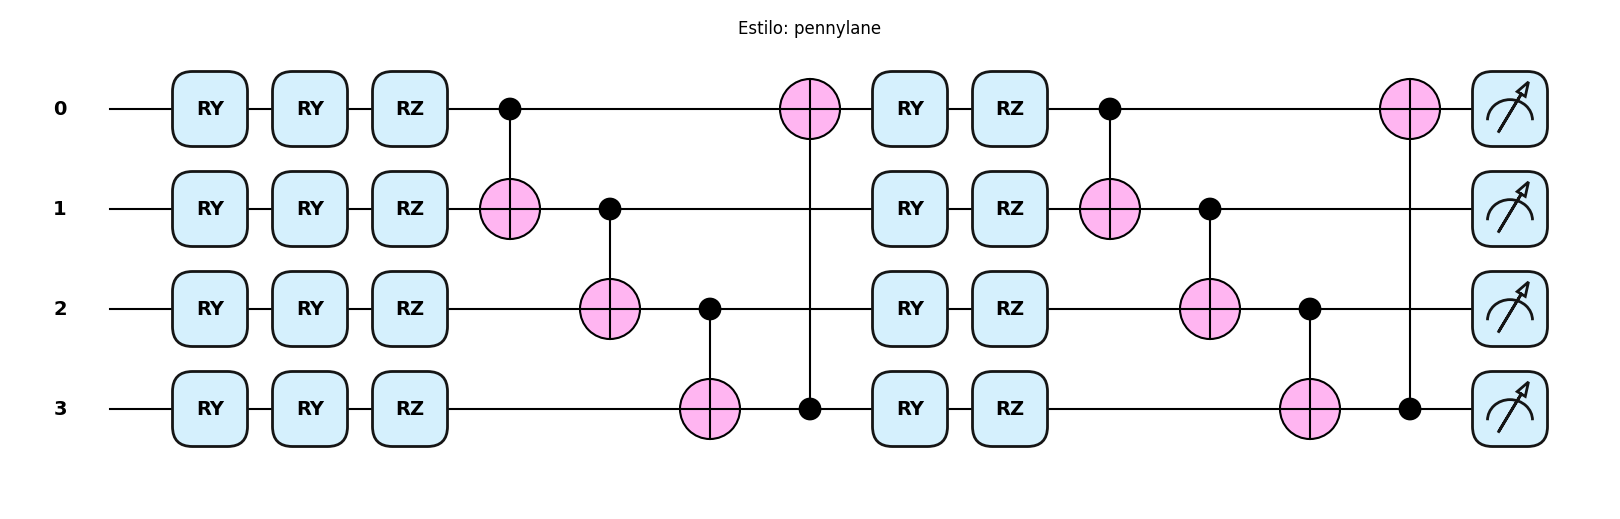

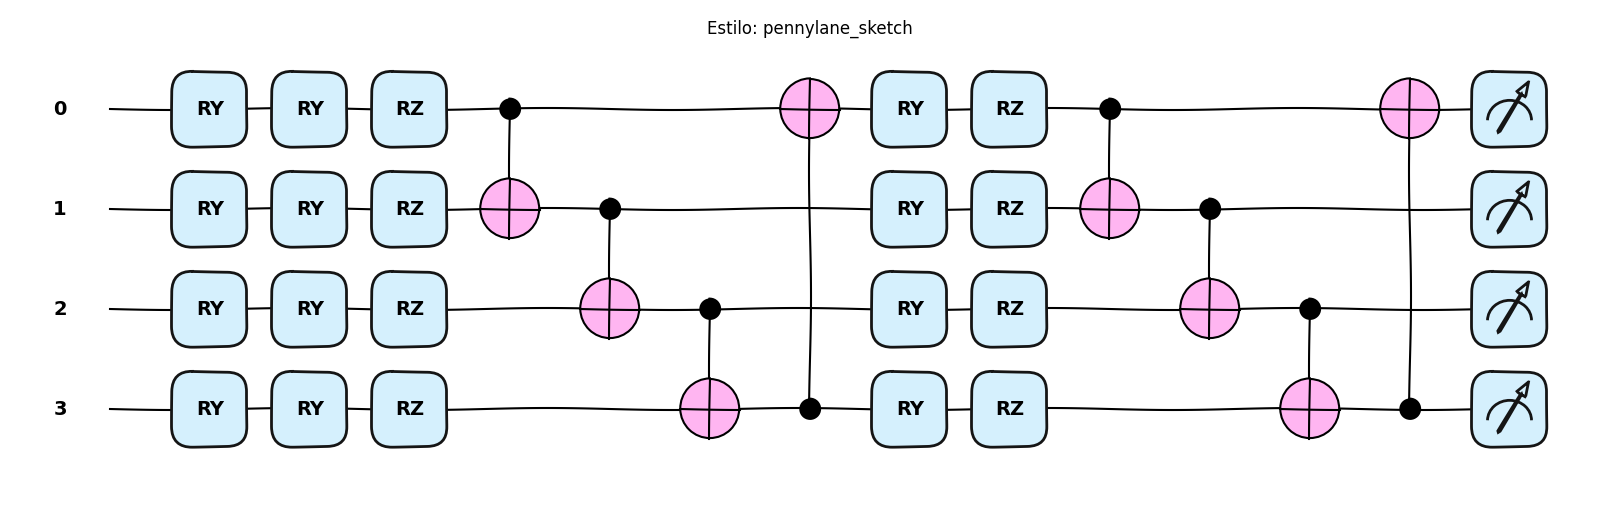

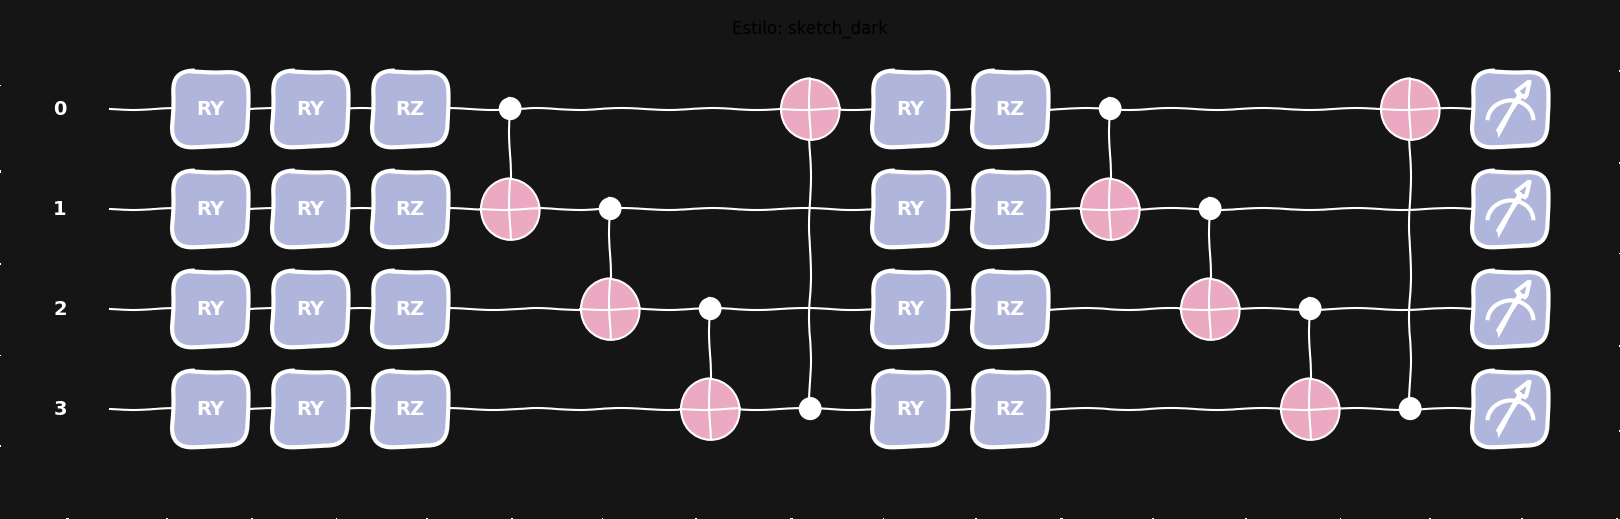

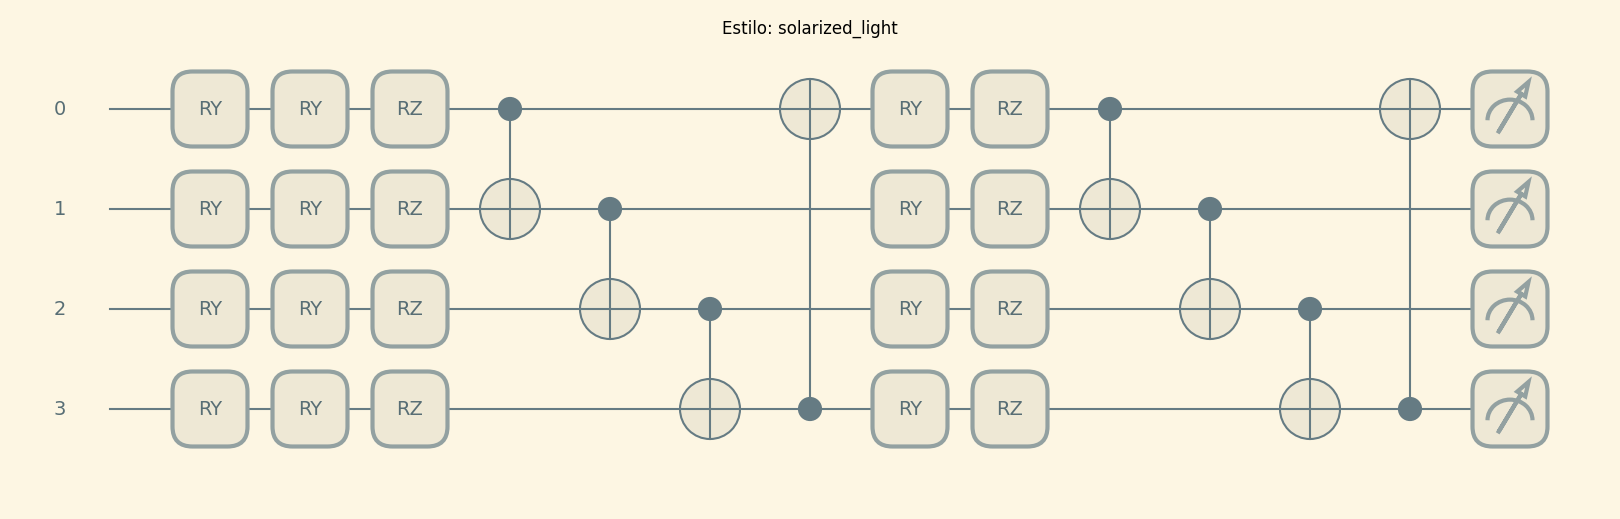

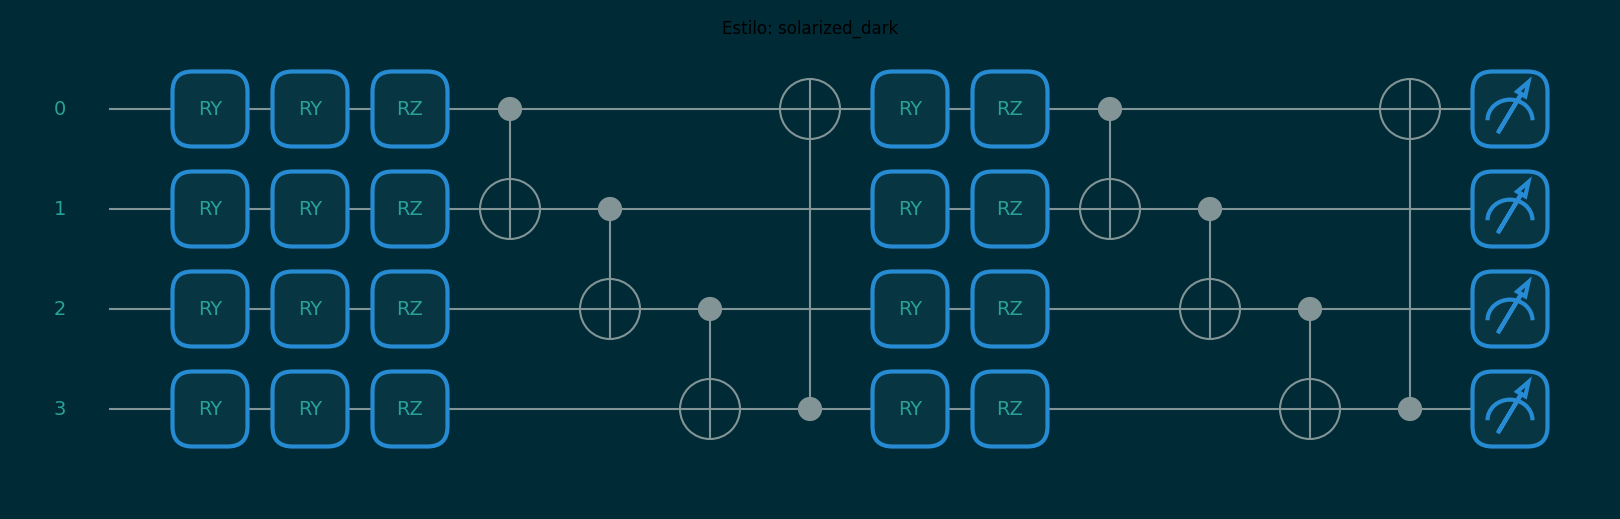

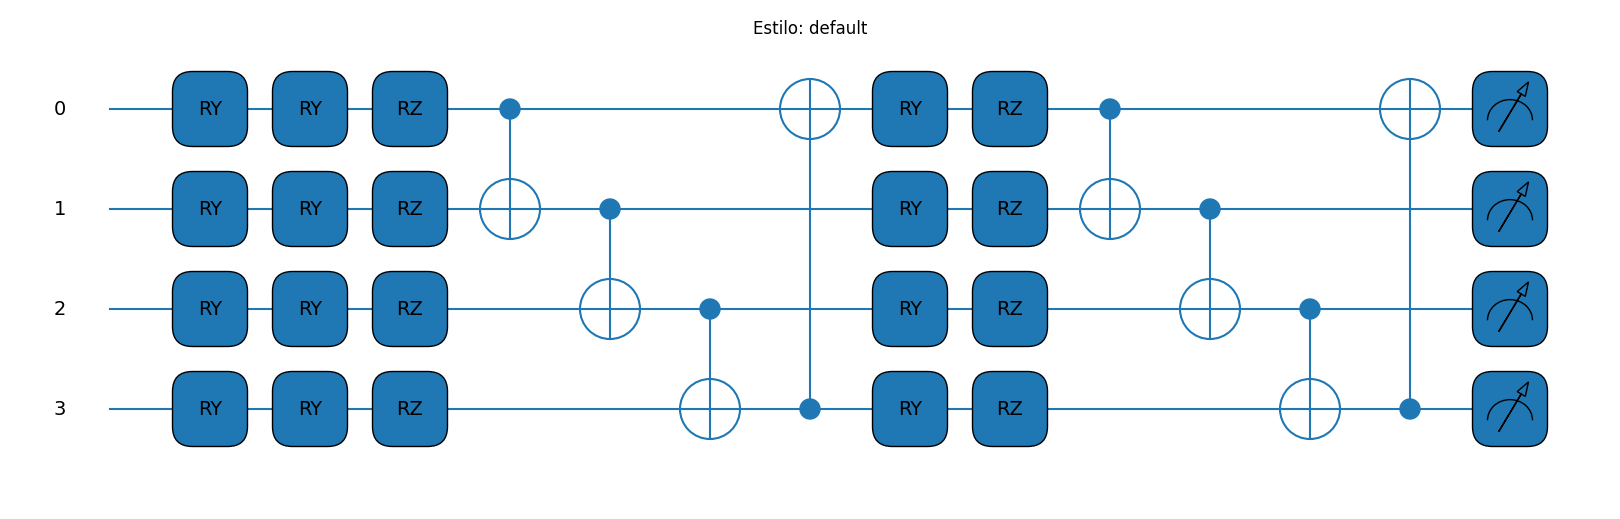

In [18]:
for estilo in qml.drawer.available_styles():
    fig, ax = qml.draw_mpl(circuito_Sebas, style=estilo)()
    fig.suptitle(f"Estilo: {estilo}")
    plt.show()

## c.

In [23]:
import pennylane as qml
from pennylane import numpy as np

dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def circuito_RY(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev)
def circuito_RZ(theta):
    qml.RZ(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

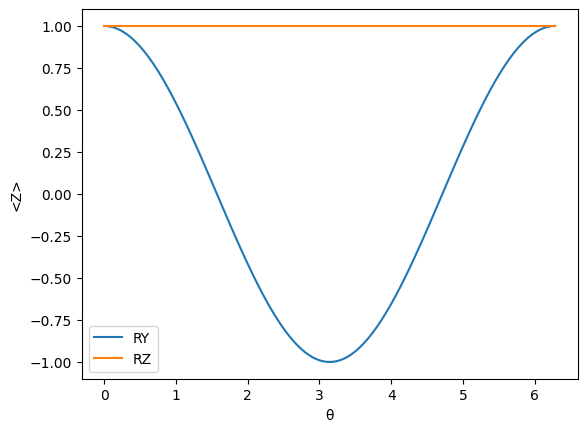

In [24]:
import matplotlib.pyplot as plt

thetas = np.linspace(0, 2*np.pi, 100)

val_RY = [circuito_RY(t) for t in thetas]
val_RZ = [circuito_RZ(t) for t in thetas]

plt.plot(thetas, val_RY, label="RY")
plt.plot(thetas, val_RZ, label="RZ")

plt.xlabel("θ")
plt.ylabel("<Z>")
plt.legend()
plt.show()